# 05 - Compact CNN Training (Mel-spectrogram)

**Objective:** Train the small Conv-BN-ReLU-Pool x2 CNN (`models/train_cnn.py build_compact_cnn`) on Mel-spectrogram features, reusing the exact model-building and augmentation functions used by the full training script.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
sys.path.insert(0, str(ML_ROOT/'models'))
import tensorflow as tf
from tensorflow import keras
from train_cnn import build_compact_cnn, load_split, normalize, CLASSES
np.random.seed(42); tf.random.set_seed(42)

`build_compact_cnn(input_shape, n_classes)` builds Conv(16)->BN->ReLU->Pool -> Conv(32)->BN->ReLU->Pool -> GlobalAvgPool -> Dense(32) -> Dense(3, softmax) — imported directly from the training script, not reimplemented here.

In [3]:
mel_train, y_train = load_split('train')
mel_val, y_val = load_split('validation')
mean, std = mel_train.mean(), mel_train.std() + 1e-8
X_train = normalize(mel_train, mean, std)[..., np.newaxis].astype(np.float32)
X_val = normalize(mel_val, mean, std)[..., np.newaxis].astype(np.float32)
input_shape = X_train.shape[1:]
model = build_compact_cnn(input_shape, len(CLASSES))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "compact_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 101, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 101, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 40, 101, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,147 (24.01 KB)

 Trainable params: 6,051 (23.64 KB)

 Non-trainable params: 96 (384.00 B)

## Short live training run (5 epochs, for notebook demonstration; the full 15-epoch early-stopped run used for model selection is `models/compact_cnn/`)

In [4]:
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.arange(3), y=y_train)
class_weight = {i: w for i, w in enumerate(cw)}
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5,
                     batch_size=32, class_weight=class_weight, verbose=2)

Epoch 1/5


263/263 - 6s - 22ms/step - accuracy: 0.6651 - loss: 0.7310 - val_accuracy: 0.1910 - val_loss: 1.0586


Epoch 2/5


263/263 - 4s - 15ms/step - accuracy: 0.7094 - loss: 0.5658 - val_accuracy: 0.6942 - val_loss: 0.8319


Epoch 3/5


263/263 - 4s - 15ms/step - accuracy: 0.7304 - loss: 0.5001 - val_accuracy: 0.2102 - val_loss: 1.2946


Epoch 4/5


263/263 - 4s - 15ms/step - accuracy: 0.7536 - loss: 0.4527 - val_accuracy: 0.7550 - val_loss: 0.5727


Epoch 5/5


263/263 - 4s - 14ms/step - accuracy: 0.7719 - loss: 0.4174 - val_accuracy: 0.7778 - val_loss: 0.5344


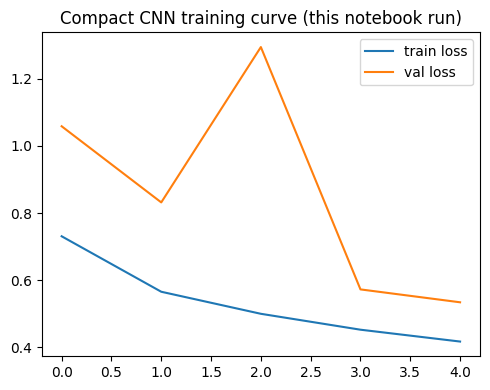

In [5]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(history.history['loss'], label='train loss')
ax.plot(history.history['val_loss'], label='val loss')
ax.legend(); ax.set_title('Compact CNN training curve (this notebook run)')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_compact_cnn_training_curve.png', dpi=120)
plt.show()

## Full training run results (models/compact_cnn/compact_cnn_metadata.json)

In [6]:
import json
meta = json.load(open(ML_ROOT/'models'/'compact_cnn'/'compact_cnn_metadata.json'))
print('Params:', meta['n_params'], 'Weights size (bytes):', meta['weights_size_bytes'])
print('Validation macro-F1 (full run):', meta['validation_metrics']['macro_f1'])
print('Test macro-F1 (full run):', meta['test_metrics']['macro_f1'])

Params: 6147 Weights size (bytes): 24588
Validation macro-F1 (full run): 0.5358079409389893
Test macro-F1 (full run): 0.32851817058577043


## Conclusion

The compact CNN (6,147 params, ~24KB FP32 weights) trains successfully on Mel-spectrogram features. Compared against the baseline and the final depthwise-separable model in notebook 06.